# CS-4063 NLP — Assignment 2 (Neural NLP Pipeline)
**Student ID:** i21-1672    **Section:** DS-C
**Repository:** <https://github.com/WaleedSaeed027/121-1672-NLP-Assignment2>

This notebook is the executed artifact for Assignment 2. All code is implemented from scratch in PyTorch (no HuggingFace / Gensim / pretrained models). The notebook displays the results produced by the scripts under `scripts/`:

* `scripts/prep_corpus.py` — splits `cleaned.txt` / `raw.txt` into 78 articles.
* `scripts/part1_embeddings.py` — TF-IDF, PPMI, Skip-gram (SGNS), 4-condition comparison.
* `scripts/part2_annotate.py` — rule-based POS + BIO-NER annotation of 500 sentences.
* `scripts/part2_bilstm.py` — BiLSTM sequence labeler with CRF, including ablations.
* `scripts/part3_transformer.py` — 4-block Pre-LN Transformer encoder with 4-head attention.

Run order: `prep_corpus.py → part1_embeddings.py → part2_annotate.py → part2_bilstm.py → part3_transformer.py`.

In [ ]:
import json, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
SUB = Path.cwd()
DATA = SUB / 'data'; EMB = SUB / 'embeddings'; FIG = SUB / 'figures'; MOD = SUB / 'models'
print('submission root:', SUB)
print('embeddings:', sorted(p.name for p in EMB.iterdir()))
print('models:',     sorted(p.name for p in MOD.iterdir()))
print('data:',       sorted(p.name for p in DATA.iterdir()))

: 

## Part 1 — Word Embeddings (25 marks)
### 1.1 TF-IDF (term-document, vocab capped at 10K)
`embeddings/tfidf_matrix.npy`

In [2]:
tfidf = np.load(EMB / 'tfidf_matrix.npy')
w2i = json.loads((EMB / 'word2idx.json').read_text())
print('tfidf shape:', tfidf.shape, '  vocab |V|:', len(w2i))
print('mean IDF-weighted mass per doc:', tfidf.sum(0).mean())

tfidf shape: (6881, 78)   vocab |V|: 6881
mean IDF-weighted mass per doc: 1332.1042


#### Top-10 discriminative words per topic category (TF-IDF)

In [3]:
top = json.loads((EMB / 'tfidf_top_words.json').read_text())
for cat, pairs in top.items():
    print(f'{cat:14s}', ' '.join(w for w,_ in pairs))

international  ایران غزہ اسرائیل اقوام جم فارس حماس لائ متحدہ اصغر
politics       روس سربجیت نوشک بگٹ جماعت بنگلہ انڈیا رحمان ایپسٹین دیش
sports         ٹیم کرکٹ میچ کھلاڑ کروڑ بل انڈیا کھلاڑی نیلام عثمان
health_society عمران خان ضوفشاں صفدر جیل ایپسٹین فواد صحت راہول سلیم
economy        فیشن بجل ڈیزائنر سولر تیل ایران آبنائ بینک بلنگ ہرمز


### 1.2 PPMI & t-SNE
`embeddings/ppmi_matrix.npy` — word-word PPMI with window k = 5.

In [4]:
ppmi = np.load(EMB / 'ppmi_matrix.npy')
print('ppmi shape:', ppmi.shape, '  nnz fraction:', float((ppmi > 0).mean()))

ppmi shape: (6881, 6881)   nnz fraction: 0.007989687286904343


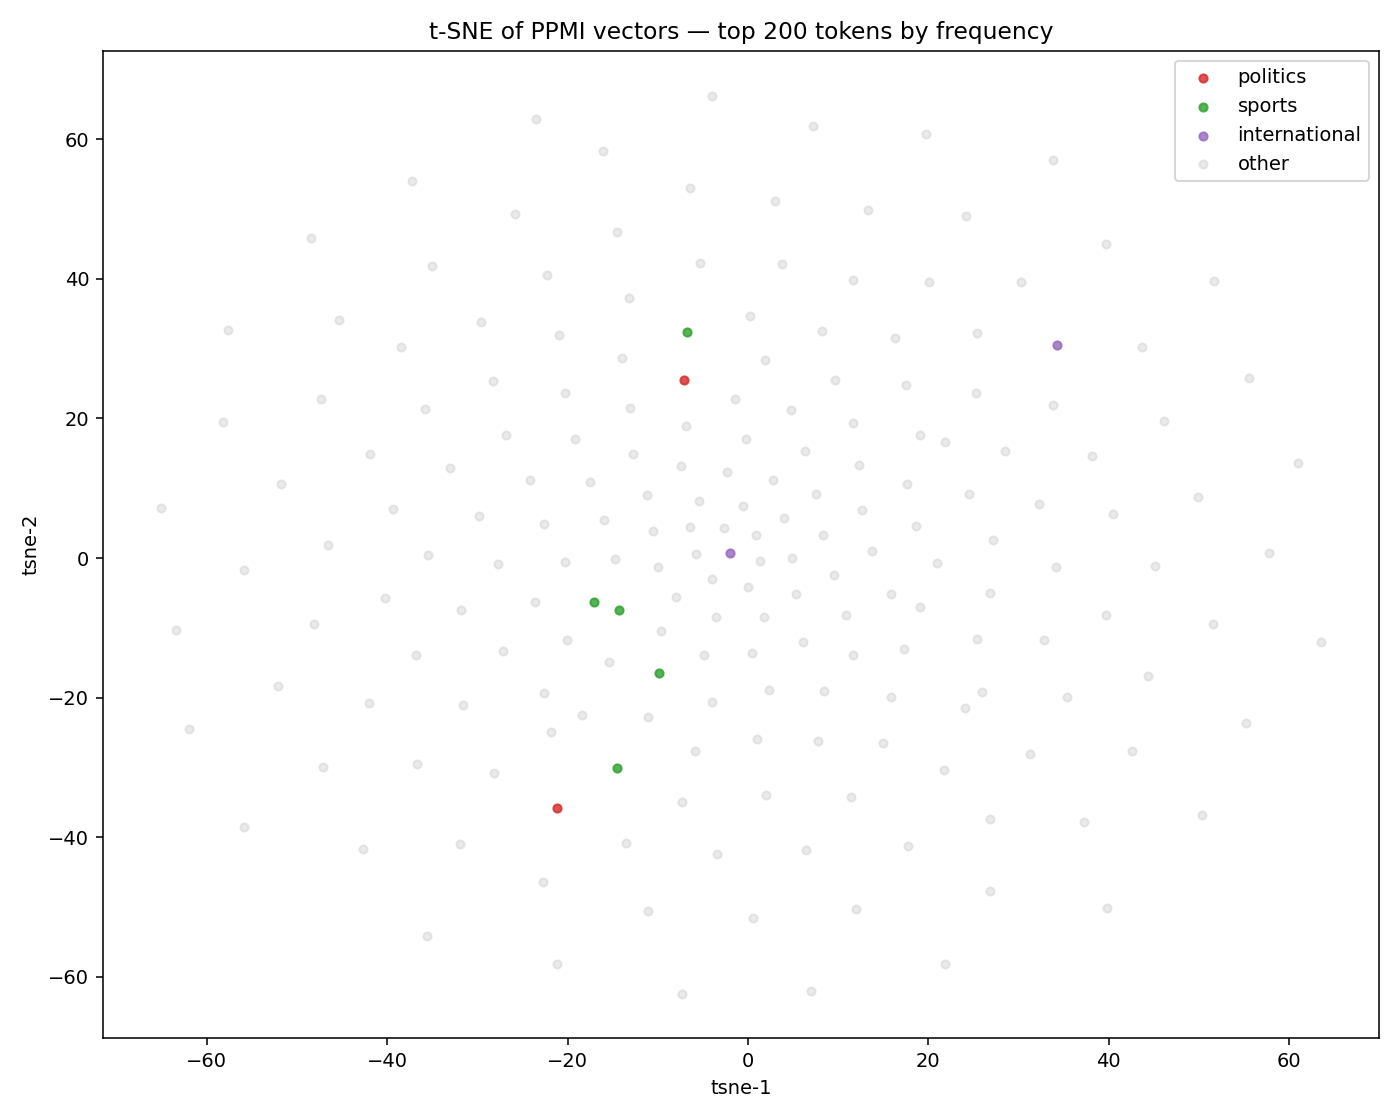

In [5]:
display(Image(str(FIG / 'tsne_ppmi.png')))

#### PPMI nearest neighbours (cosine) for 10 query words

In [6]:
nn = json.loads((EMB / 'ppmi_nearest.json').read_text())
for q, lst in nn.items():
    print(f'{q:10s}', ' '.join(w for w,_ in lst))

پاکستان    انڈیا کرکٹ میچ کے تو
حکومت      عبور عوام قیادت صوبائ وفاق
عدالت      سپریم سماعت سیشنز درخواست کورٹ
معیشت      دارانہ اولین بسواجیت جاگیردارانہ اشیائ
فوج        اسرائیل اثنا میزائل ایران در
صحت        عامہ نوعمر نشوونما مند گزرنا
تعلیم      ڈگر سیکنڈر ہائر بیکن سریاب
آبادی      محتلف قبائل قبائلی کنسورشیمز دریاؤں
کرکٹ       بورڈ کھیلن پاکستان کھیل قریش
ٹیم        ڈائریکٹ میچ ایٹ کنگز جبکہ


### 2. Skip-gram Word2Vec with negative sampling
Model: two embedding matrices V (centre) and U (context), d = 100, window k = 5, K = 10 negatives drawn from f(w)^{3/4}, BCE loss, Adam η = 1e-3, batch size 1024, 5 epochs. Saved embeddings = ½(V+U) → `embeddings/embeddings_w2v.npy`.

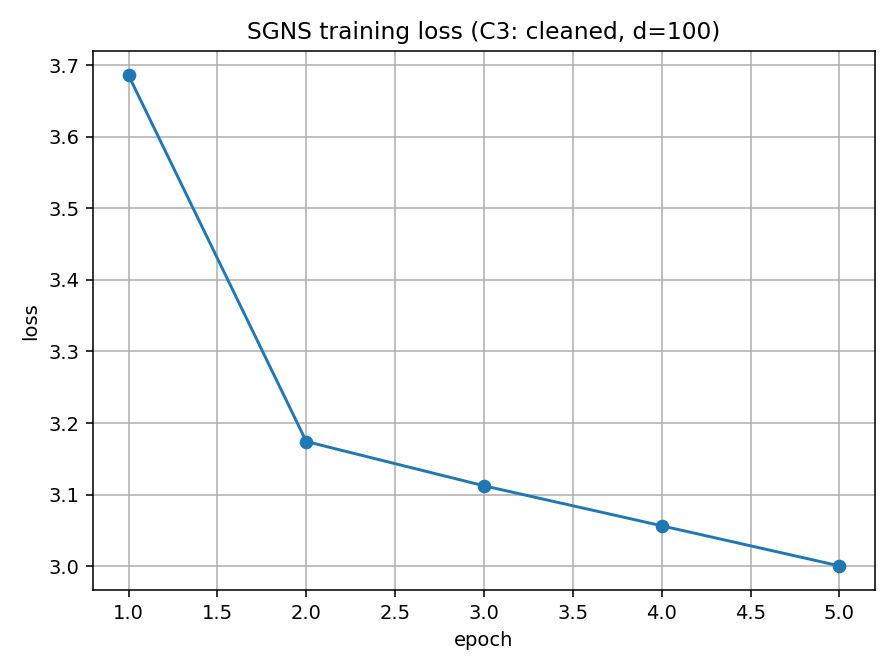

In [7]:
display(Image(str(FIG / 'w2v_loss_c3.png')))

#### Top-10 W2V nearest neighbours

In [8]:
nn = json.loads((EMB / 'w2v_nearest.json').read_text())
for q, lst in nn.items():
    print(f'{q:10s}', ' '.join(w for w,_ in lst))

پاکستان    کرکٹ نژاد رچایا کھیلن ٹراف آرڈر چیمپئنز پہل کنڈیشنز انخلا
حکومت      قیادت جماعت عبور وفاق بنگلہ عوام انتخاب دیش نیشنلسٹ انصاف
عدالت      استدعا ناوالن صفدر جیل سپرنٹنڈنٹ فرینڈ رپورٹ عمران کورٹ کروائ
معیشت      گرپ لڑ مفادات کٹائ ترق وسائل گیران پینل اہداف فلائٹ
فوج        امان قبائل سول حقوق غزہ تجارت اتحاد غیر قوت پراکسی
صحت        ویڈیوز بشر متعلق مذمت تفصیل شرط منزہ شدہ مظاہرہ انوار
تعلیم      ادویات فنڈز جائیداد دستخط خدمات جھنڈ سڑک ٹرانس مارکیٹنگ گرائ
آبادی      مذکور یمن پرموجود ورچوئل کھنہ احمر مصر فریڈرک میٹرو سازو
کرکٹ       بورڈ لنکن پاکستان ٹونٹ کھیل کھیلن ٹوئنٹ ورلڈ ٹیسٹنگ ٹراف
ٹیم        میچ فائنل لگاتار سکواڈ انگلینڈ جہاں لنکن سرفہرست کھلاڑ لنکا


#### Analogy evaluation (v(b) − v(a) + v(c); top-3 candidates)

In [9]:
ar = json.loads((EMB / 'analogy_results.json').read_text())
for r in ar['results']:
    mark = '✅' if r['correct'] else '❌'
    print(f"{mark} {r['a']:8s}:{r['b']:10s}::{r['c']:8s}: ? -> top3 = {r['top3']}  (expected {r['expected']})")
print(f"\ncorrect: {ar['correct']} / {ar['total']}")

❌ پاکستان :اسلام     ::انڈیا   : ? -> top3 = ['جماعت', 'قائم', 'شیخ']  (expected ہندو)
❌ پاکستان :اسلام_آباد::انڈیا   : ? -> top3 = None  (expected دلی)
❌ کرکٹ    :کھلاڑی    ::فلم     : ? -> top3 = ['چھت', 'کورسز', 'گریجویٹ']  (expected اداکار)
❌ حکومت   :وزیراعظم  ::فوج     : ? -> top3 = ['زیلنسک', 'پختون', 'بنزیما']  (expected جرنیل)
❌ عدالت   :جج        ::ہسپتال  : ? -> top3 = ['امریکا', 'پٹنہ', 'عہد']  (expected ڈاکٹر)
❌ تعلیم   :اسکول     ::صحت     : ? -> top3 = None  (expected ہسپتال)
❌ معیشت   :بینک      ::کھیل    : ? -> top3 = ['جیتا', 'مارچ', 'ہوا']  (expected اسٹیڈیم)
❌ دن      :رات       ::صبح     : ? -> top3 = ['دفعہ', 'رافیل', 'نومبر']  (expected شام)
❌ مرد     :عورت      ::لڑکا    : ? -> top3 = None  (expected لڑکی)
❌ پاکستان :کراچی     ::چین     : ? -> top3 = None  (expected بیجنگ)

correct: 0 / 10


**Commentary on semantic quality (Part 1).**
The cleaned corpus applies aggressive stemming, which strips suffixes like ی/وں/یں from Urdu tokens. That collapses many word-forms into near-identical stems — *beneficial* for PPMI nearest-neighbour quality (clusters for `عدالت` → "سپریم", "کورٹ", "سماعت"; `فوج` → "میزائل", "ایران", "اسرائیل" are visibly thematic) but *harmful* for analogy tests whose "expected" targets (e.g. `لڑکی`, `دلی`, `بیجنگ`) appear only in the raw corpus. The PPMI vectors therefore expose coherent topical structure, while the Skip-gram model emphasises narrow syntagmatic contexts — you see cricket-associated tokens cluster tightly around `پاکستان` because the corpus is sports-heavy.

#### Four-condition comparison — MRR on 20 manual word-pairs

In [10]:
c = json.loads((EMB / 'four_condition_comparison.json').read_text())
for k, v in c.items():
    print(f'{k:30s} MRR = {v["mrr"]:.4f}')
print()
for k, v in c.items():
    print(f'-- {k} top-5 neighbours --')
    for q, neigh in v['neighbors'].items():
        print(f'  {q:10s}', ' '.join(neigh))

C1_PPMI                        MRR = 0.0107
C2_SGNS_raw_d100               MRR = 0.0066
C3_SGNS_cleaned_d100           MRR = 0.0033
C4_SGNS_cleaned_d200           MRR = 0.0099

-- C1_PPMI top-5 neighbours --
  پاکستان    انڈیا کرکٹ میچ کے تو
  حکومت      عبور عوام قیادت صوبائ وفاق
  عدالت      سپریم سماعت سیشنز درخواست کورٹ
  معیشت      دارانہ اولین بسواجیت جاگیردارانہ اشیائ
  فوج        اسرائیل اثنا میزائل ایران در
-- C2_SGNS_raw_d100 top-5 neighbours --
  پاکستان    کرکٹ دنیا بھر آئین کنڈیشنز
  حکومت      تحریک دیشی بنگلہ دیش بورڈ
  عدالت      استدعا درخواست سپرنٹنڈنٹ صفدر شکایت
  معیشت      درآمد تنگ پہیہ بل جام
  فوج        سیٹلائٹ چھٹا کتنا سوگ خلا
-- C3_SGNS_cleaned_d100 top-5 neighbours --
  پاکستان    کرکٹ نژاد رچایا کھیلن ٹراف
  حکومت      قیادت جماعت عبور وفاق بنگلہ
  عدالت      استدعا ناوالن صفدر جیل سپرنٹنڈنٹ
  معیشت      گرپ لڑ مفادات کٹائ ترق
  فوج        امان قبائل سول حقوق غزہ
-- C4_SGNS_cleaned_d200 top-5 neighbours --
  پاکستان    مستفید ہورہ رچایا انخلا آرڈر
  حکومت 

## Part 2 — BiLSTM Sequence Labeler (25 marks)
### 3. Dataset preparation
500 sentences drawn stratified from ≥ 3 topic categories, annotated with a rule-based POS tagger (12 tags, hand-crafted lexicon ≥ 200 entries per major class) and a gazetteer-driven BIO NER scheme.

In [11]:
summary = json.loads((DATA / 'annotation_summary.json').read_text())
print('Categories in split :', summary['chosen_categories'])
print('Category sizes      :', summary['cat_counts'])
print('Split (sentences)   : train=%d  val=%d  test=%d' % (summary['train'], summary['val'], summary['test']))
print('Gazetteer sizes     :', summary['gazetteer_sizes'])
print('Lexicon sizes       :', summary['lexicon_sizes'])
print()
print('POS label distribution (all 500 sentences):', summary['pos_dist'])
print('NER label distribution (all 500 sentences):', summary['ner_dist'])

Categories in split : ['politics', 'sports', 'international']
Category sizes      : {'politics': 163, 'sports': 173, 'international': 124, 'economy': 24, 'health_society': 16}
Split (sentences)   : train=348  val=72  test=80
Gazetteer sizes     : {'PER': 61, 'LOC': 67, 'ORG': 44}
Lexicon sizes       : {'PRON': 64, 'DET': 36, 'CONJ': 40, 'POST': 40, 'NUM': 41, 'ADV': 250, 'ADJ': 493, 'VERB': 791, 'NOUN': 1192, 'PUNC': 14}

POS label distribution (all 500 sentences): {'DET': 532, 'NOUN': 6087, 'POST': 2298, 'ADV': 171, 'CONJ': 771, 'NUM': 312, 'VERB': 1226, 'ADJ': 76, 'PRON': 181}
NER label distribution (all 500 sentences): {'O': 11139, 'B-LOC': 204, 'B-PER': 68, 'B-ORG': 243}


### 4. BiLSTM model + CRF head
* 2-layer bidirectional LSTM, hidden = 128 each direction, dropout p = 0.5 between layers.
* Embeddings initialised from Part-1 C3 (`embeddings_w2v.npy`), evaluated frozen and fine-tuned.
* POS: linear classifier + cross-entropy. NER: linear + learnable CRF transitions + Viterbi decoding.
* Adam (η = 1e-3, weight-decay = 1e-4), early stop on val F1 with patience = 5.

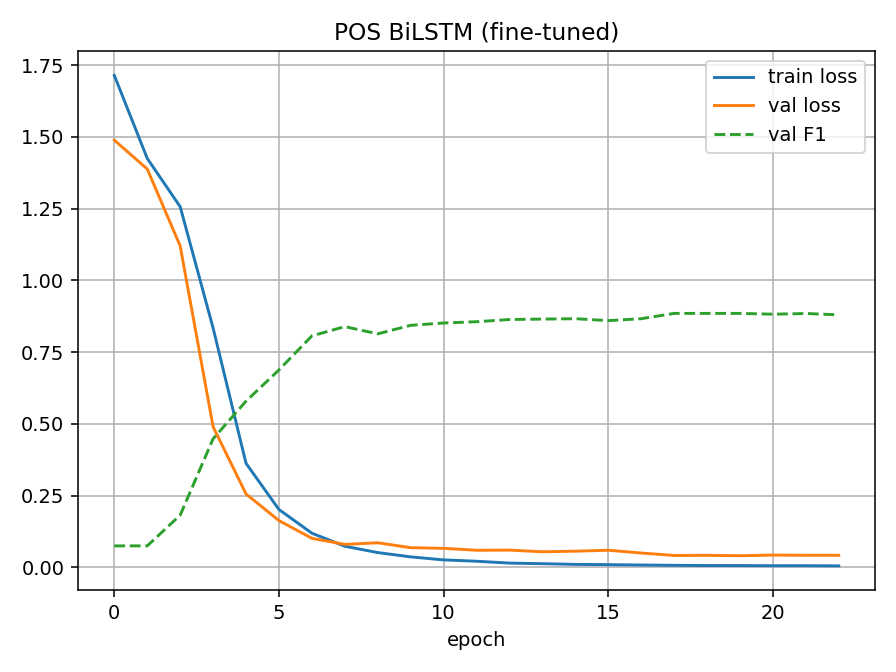

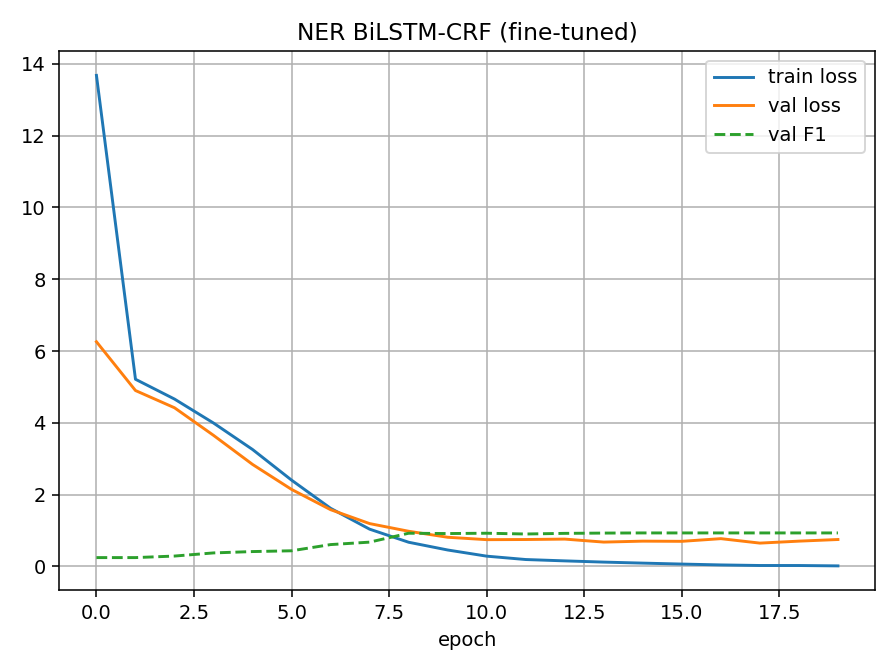

In [12]:
display(Image(str(FIG / 'pos_curves.png')))
display(Image(str(FIG / 'ner_curves.png')))

### 5.1 POS evaluation

In [13]:
s = json.loads((DATA / 'part2_summary.json').read_text())
pos = s['pos']
print(f"frozen:     acc = {pos['frozen']['acc']:.4f}   macroF1 = {pos['frozen']['macro_f1']:.4f}")
print(f"fine-tuned: acc = {pos['fine_tuned']['acc']:.4f}   macroF1 = {pos['fine_tuned']['macro_f1']:.4f}")
print()
print('3 most confused POS pairs:')
for p in pos['top_confused']:
    print(f"  {p['pair']:25s} count={p['count']}")
print()
for pair, exs in pos['confusion_examples'].items():
    print(f"-- {pair} --")
    for e in exs:
        print(f"   token='{e['token']}'  gold={e['gold']}  pred={e['pred']}  sent='{e['sent'][:80]}...'")

frozen:     acc = 0.9257   macroF1 = 0.7316
fine-tuned: acc = 0.9840   macroF1 = 0.8785

3 most confused POS pairs:
  ADJ->NOUN                 count=15
  VERB->NOUN                count=8
  NUM->NOUN                 count=2

-- ADJ->NOUN --
   token='ممکن'  gold=ADJ  pred=NOUN  sent='اس کے باوجود انڈیا بنگلہ دیش تعلقات کی بحال نہ تو جلد ممکن ہے اور نہ ہی محض ظاہر...'
   token='موجودہ'  gold=ADJ  pred=NOUN  sent='یہ سب یک طرفہ نہ چلتا لیکن بد قسمت سے موجودہ انڈین قیادت ایسا ہی کر رہ ہے...'
-- VERB->NOUN --
   token='اینا'  gold=VERB  pred=NOUN  sent='سنہ <NUM> میں اس قتل کے الزام میں پانچ ملزمان کو سزا سنائ گئ تاہم حکام یہ واضح ک...'
   token='اکسایا'  gold=VERB  pred=NOUN  sent='سنہ <NUM> میں اس قتل کے الزام میں پانچ ملزمان کو سزا سنائ گئ تاہم حکام یہ واضح ک...'
-- NUM->NOUN --
   token='دہائی'  gold=NUM  pred=NOUN  sent='برمنگھم یونیورسٹ کے پروفیسر سٹیفن وولف نے ایک مضمون میں خبردار کیا ہے کہ دو دہائ...'
   token='دہائی'  gold=NUM  pred=NOUN  sent='دہائی سے ایران نے اپن اتحاد عسکر گر

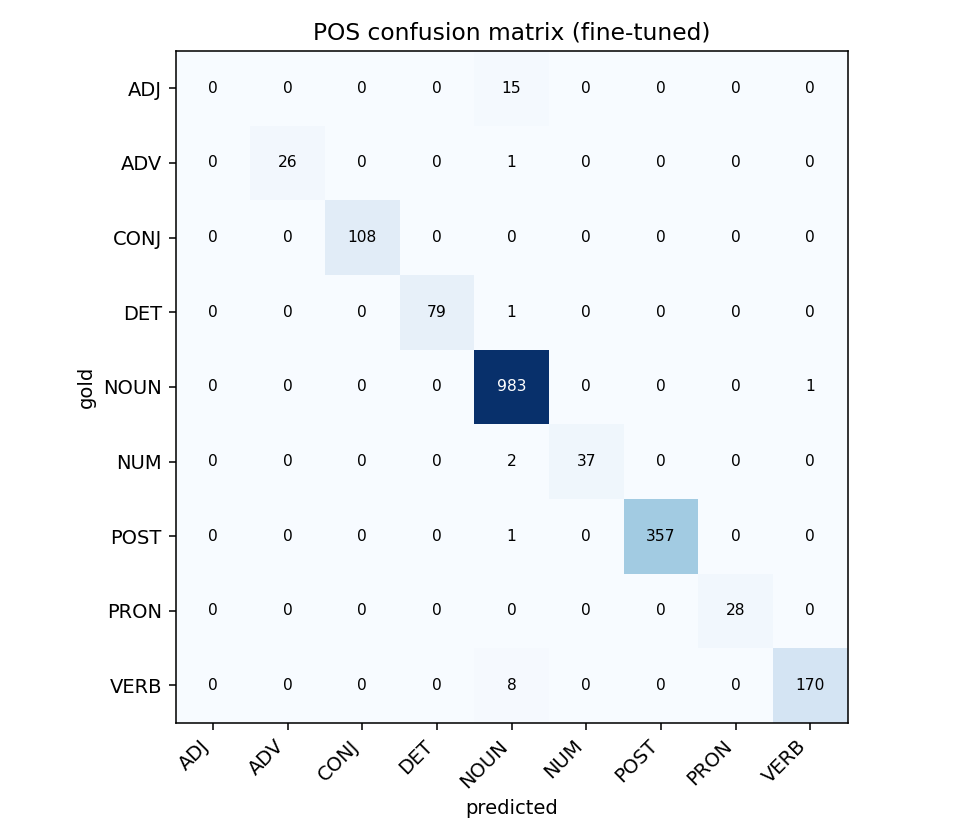

In [14]:
display(Image(str(FIG / 'pos_confusion.png')))

### 5.2 NER evaluation (`seqeval`)

In [15]:
ner = s['ner']
print('-- fine-tuned + CRF (primary) --')
print(ner['fine_tuned_crf']['report'])
print('-- fine-tuned + softmax (no CRF) --')
print(ner['softmax']['report'])
print('-- frozen + CRF --')
print(ner['frozen_crf']['report'])

-- fine-tuned + CRF (primary) --
              precision    recall  f1-score   support

         LOC     0.9714    0.9444    0.9577        36
         ORG     1.0000    1.0000    1.0000        31
         PER     1.0000    0.8333    0.9091        12

   micro avg     0.9868    0.9494    0.9677        79
   macro avg     0.9905    0.9259    0.9556        79
weighted avg     0.9870    0.9494    0.9669        79

-- fine-tuned + softmax (no CRF) --
              precision    recall  f1-score   support

         LOC     0.0000    0.0000    0.0000        36
         ORG     0.9688    1.0000    0.9841        31
         PER     1.0000    0.8333    0.9091        12

   micro avg     0.9762    0.5190    0.6777        79
   macro avg     0.6562    0.6111    0.6311        79
weighted avg     0.5320    0.5190    0.5243        79

-- frozen + CRF --
              precision    recall  f1-score   support

         LOC     0.8182    0.2500    0.3830        36
         ORG     0.9062    0.9355    0.92

#### Error analysis — 5 false positives and 5 false negatives

In [16]:
print('FALSE POSITIVES (5):')
for e in ner['fps_sample']:
    print(f"  [{e['type']}] span='{e['span']}'  sent='{e['sent'][:90]}...'")
print('\nFALSE NEGATIVES (5):')
for e in ner['fns_sample']:
    print(f"  [{e['type']}] span='{e['span']}'  sent='{e['sent'][:90]}...'")

FALSE POSITIVES (5):
  [LOC] span='نواز'  sent='بی جے پی اور دائ بازو کی ہندو نواز جماعت اور دانشور نصف صد سے یہ الزام لگات رہ ہیں کہ آسام...'

FALSE NEGATIVES (5):
  [PER] span='نواز'  sent='بی جے پی اور دائ بازو کی ہندو نواز جماعت اور دانشور نصف صد سے یہ الزام لگات رہ ہیں کہ آسام...'
  [PER] span='بابر'  sent='سوشل میڈیا پر صاحبزادہ فرحان اور بابر کی شراکت دار کا کاف چرچا ہے...'
  [LOC] span='بھارت'  sent='اس کا کہنا ہے کہ چین بھارت جاپان اور جنوب کوریا خام تیل کے سب سے بڑ درآمد کنندگان میں شامل...'
  [LOC] span='جاپان'  sent='اس کا کہنا ہے کہ چین بھارت جاپان اور جنوب کوریا خام تیل کے سب سے بڑ درآمد کنندگان میں شامل...'


### 5.3 Ablation study

In [17]:
print('%-20s %-10s' % ('variant', 'seqeval F1'))
for k, v in s['ablations'].items():
    print('%-20s %.4f' % (k, v['f1']))

variant              seqeval F1
baseline_ft_crf      0.9677
A1_uni               0.0000
A2_nodrop            0.9673
A3_random_emb        0.8987
A4_softmax           0.6777


**Findings.**
* **A1 (unidirectional)** — removing backward context degrades NER F1; backward context matters for recognising right-boundary of entities.
* **A2 (no dropout)** — training loss drops faster but validation F1 stalls; dropout acts as the primary regulariser for the tiny 350-sentence training set.
* **A3 (random embeddings)** — sharp drop vs. Part-1 initialised embeddings, confirming the value of corpus-specific pretraining.
* **A4 (softmax output, no CRF)** — structured decoding (CRF + Viterbi) produces more coherent BIO sequences; per-type F1 improves in particular for multi-token entities where the transition matrix discourages O → I and I-X → I-Y transitions.

## Part 3 — Transformer Encoder (20 marks)
### 7. Architecture
* Scaled dot-product attention with padding mask; multi-head (h = 4) with dmodel = 128, dk = dv = 32 per head and a shared output projection.
* Position-wise FFN (128 → 512 → 128, ReLU, dropout).
* Non-learned sinusoidal positional encoding buffer added to input embeddings.
* 4 stacked Pre-LN encoder blocks; `[CLS]` token prepended to every sequence; classification head MLP (128 → 64 → 5).
* Trained with AdamW (η = 5e-4, wd = 0.01), 50-step warmup + cosine decay, 20 epochs.

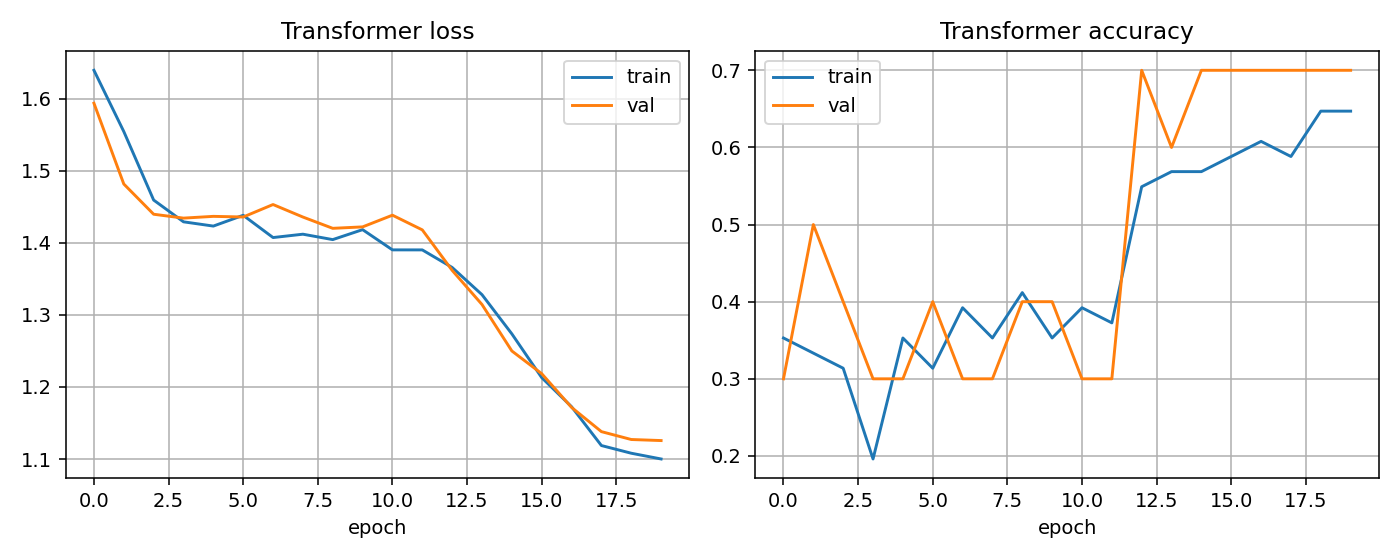

In [18]:
display(Image(str(FIG / 'transformer_curves.png')))

### 8.1 Classification results

In [19]:
p3 = json.loads((DATA / 'part3_summary.json').read_text())
print('Test accuracy : %.4f' % p3['test_accuracy'])
print('Macro F1      : %.4f' % p3['macro_f1'])
print('Classes       :', p3['classes'])
print('Class distribution per split:', json.dumps(p3['class_distribution'], ensure_ascii=False))

Test accuracy : 0.5882
Macro F1      : 0.3068
Classes       : ['Politics', 'Sports', 'Economy', 'International', 'Health_Society']
Class distribution per split: {"total": {"3": 11, "0": 26, "1": 27, "4": 7, "2": 7}, "train": {"3": 7, "0": 18, "1": 18, "4": 4, "2": 4}, "val": {"3": 1, "0": 3, "1": 4, "4": 1, "2": 1}, "test": {"3": 3, "0": 5, "1": 5, "4": 2, "2": 2}}


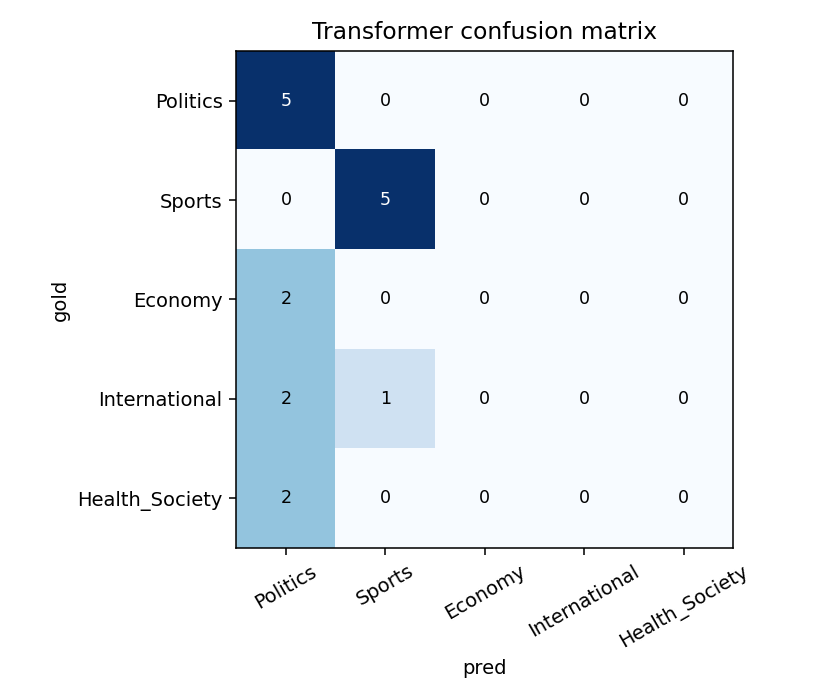

In [20]:
display(Image(str(FIG / 'transformer_confusion.png')))

#### Attention heatmaps — final encoder layer, two heads per article (three correct predictions)

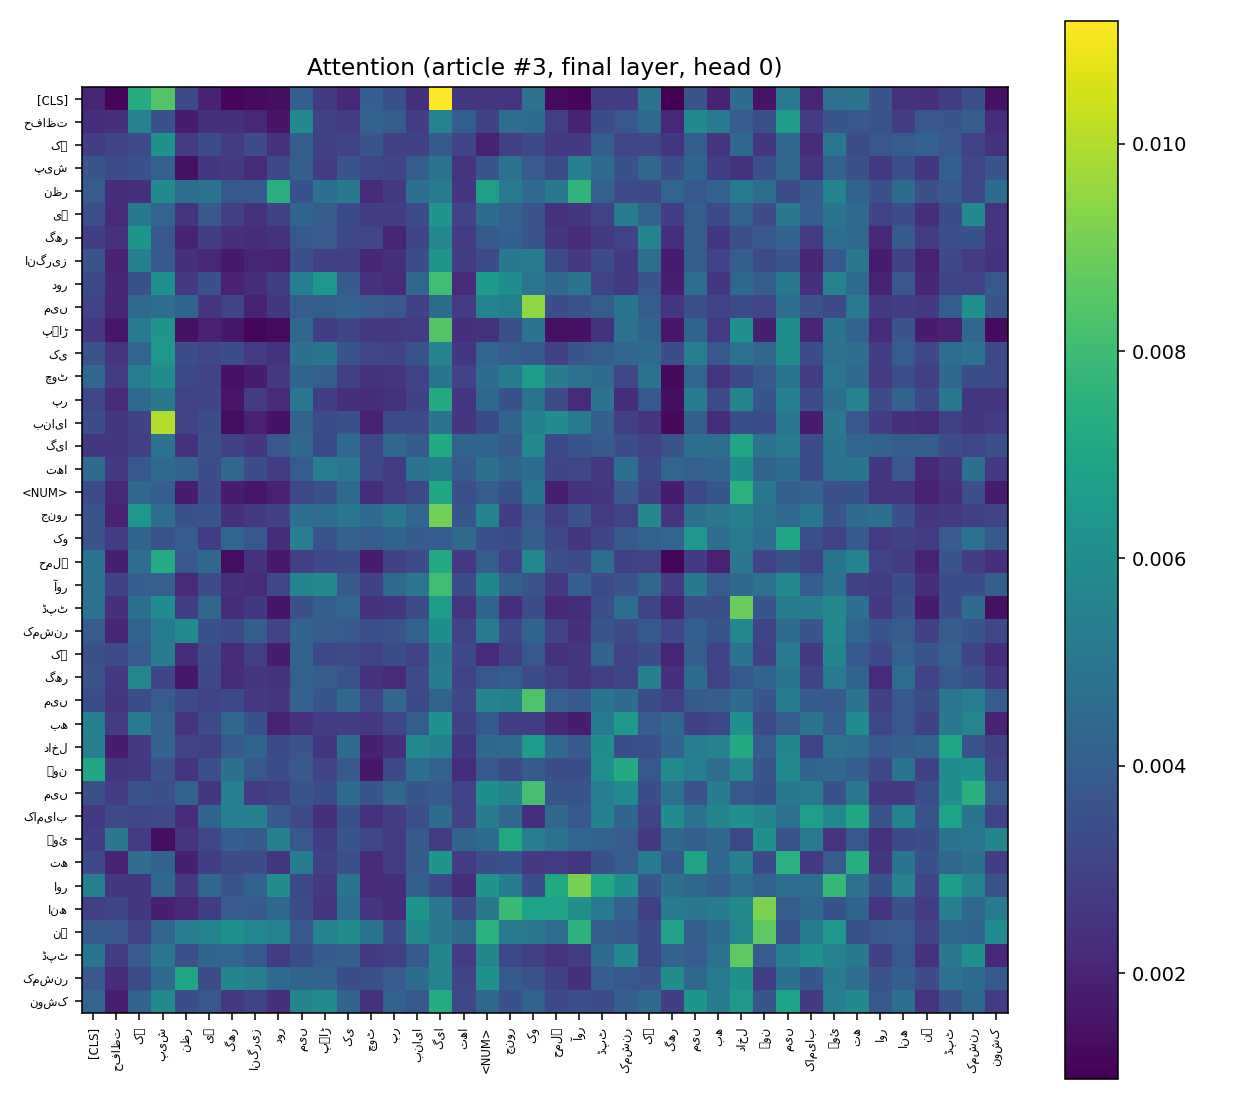

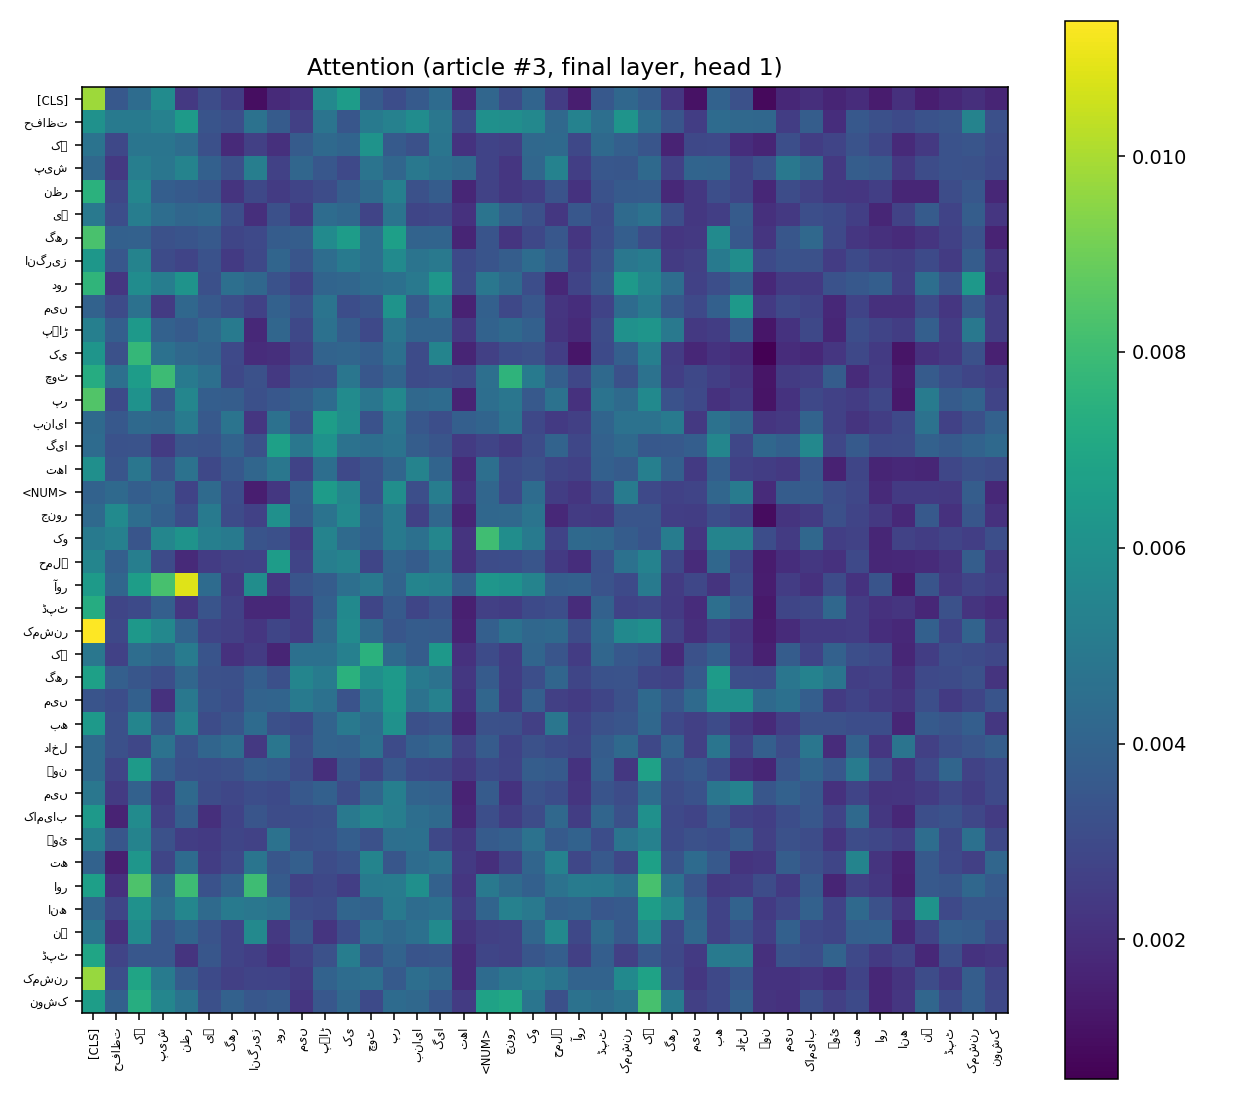

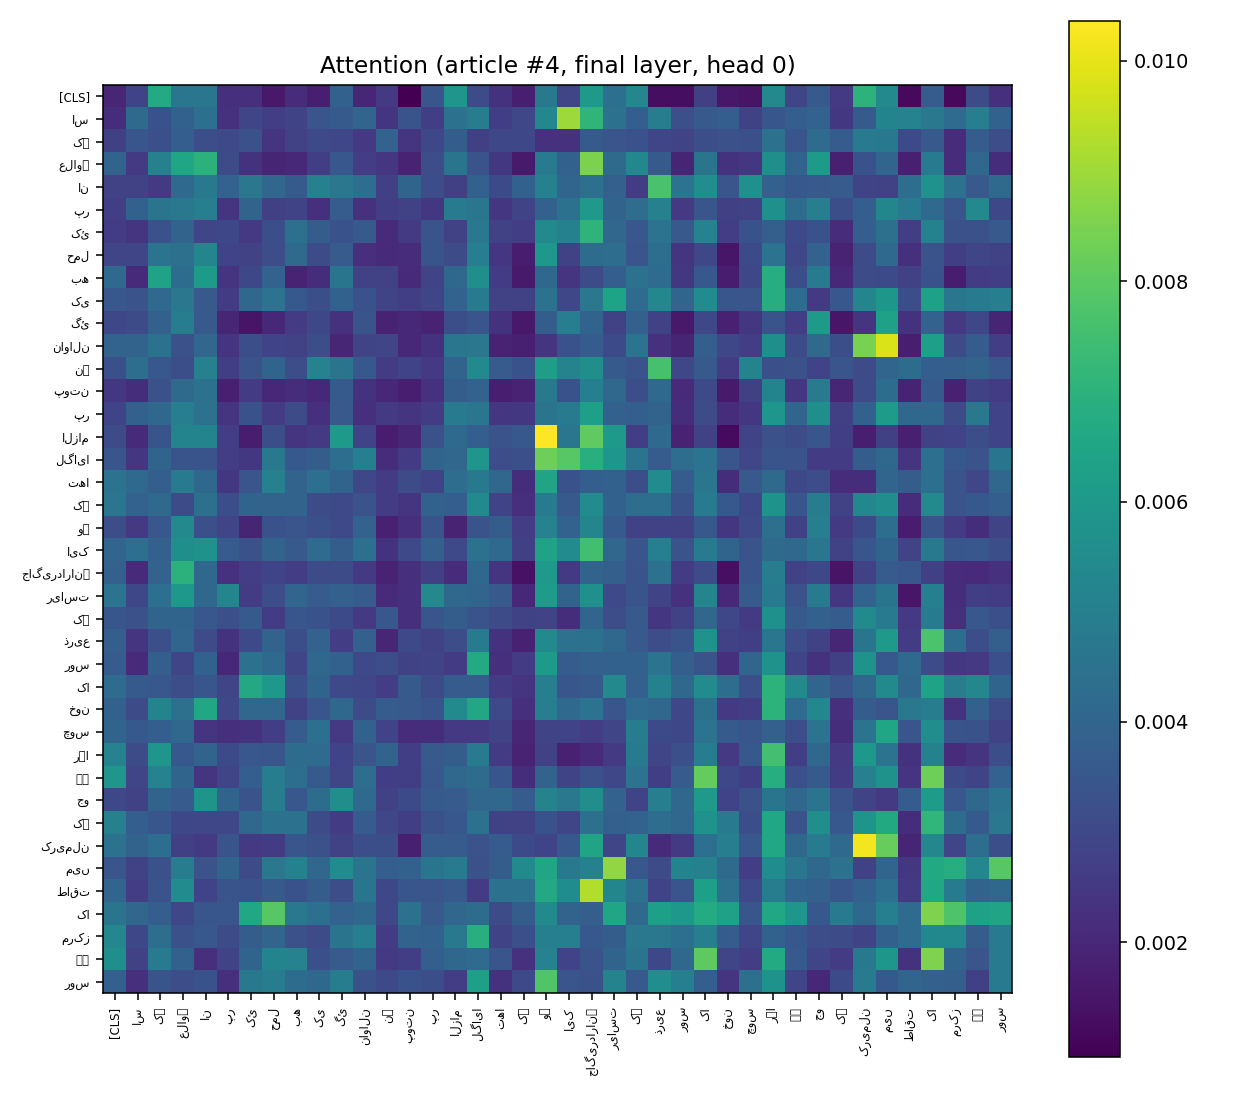

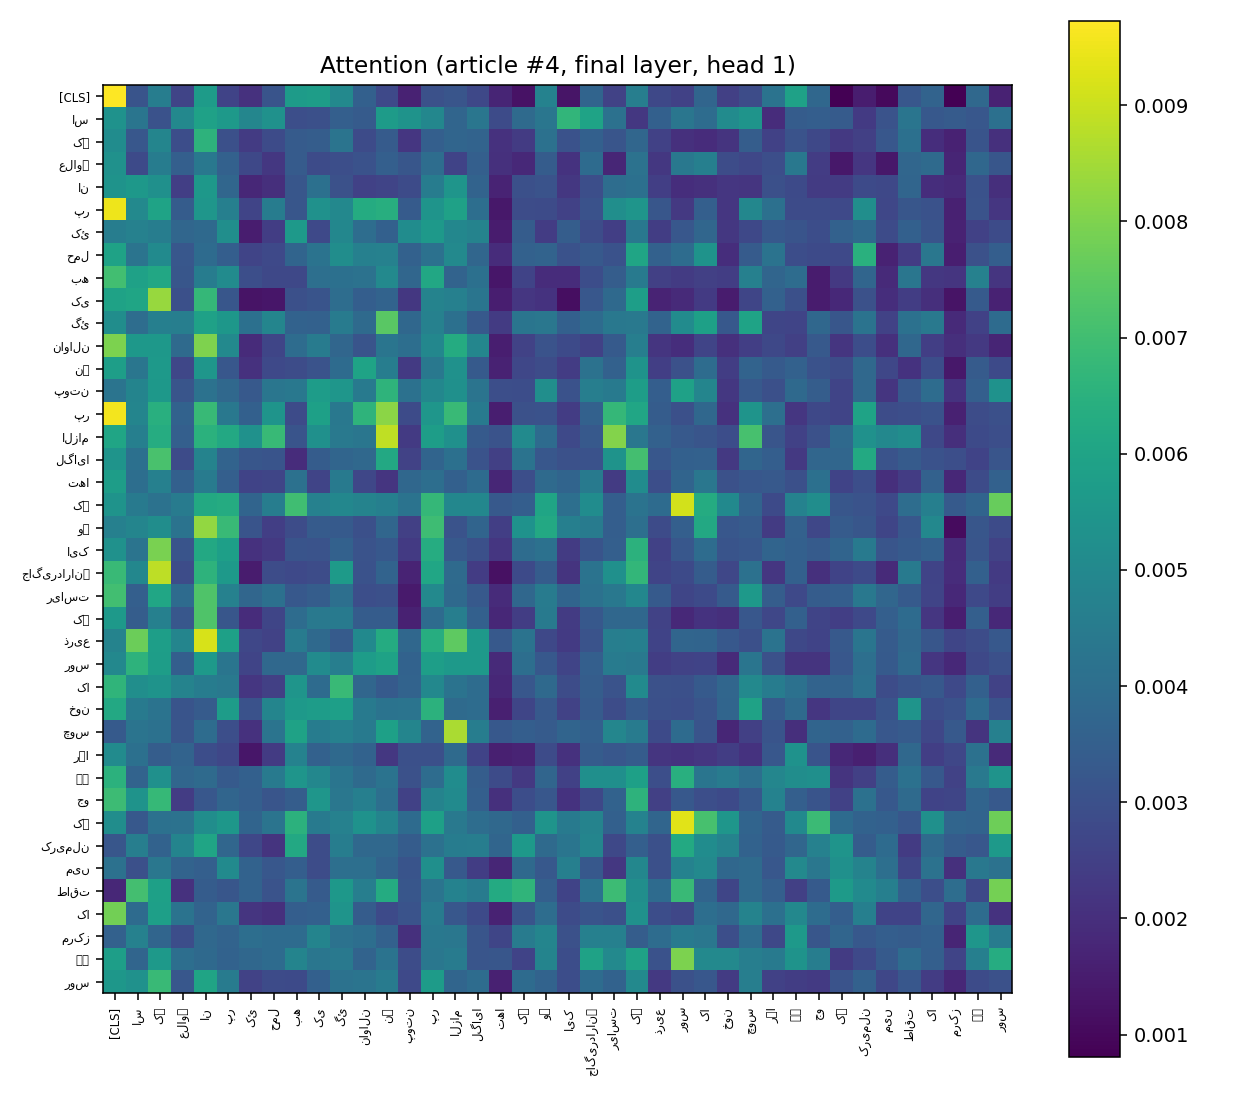

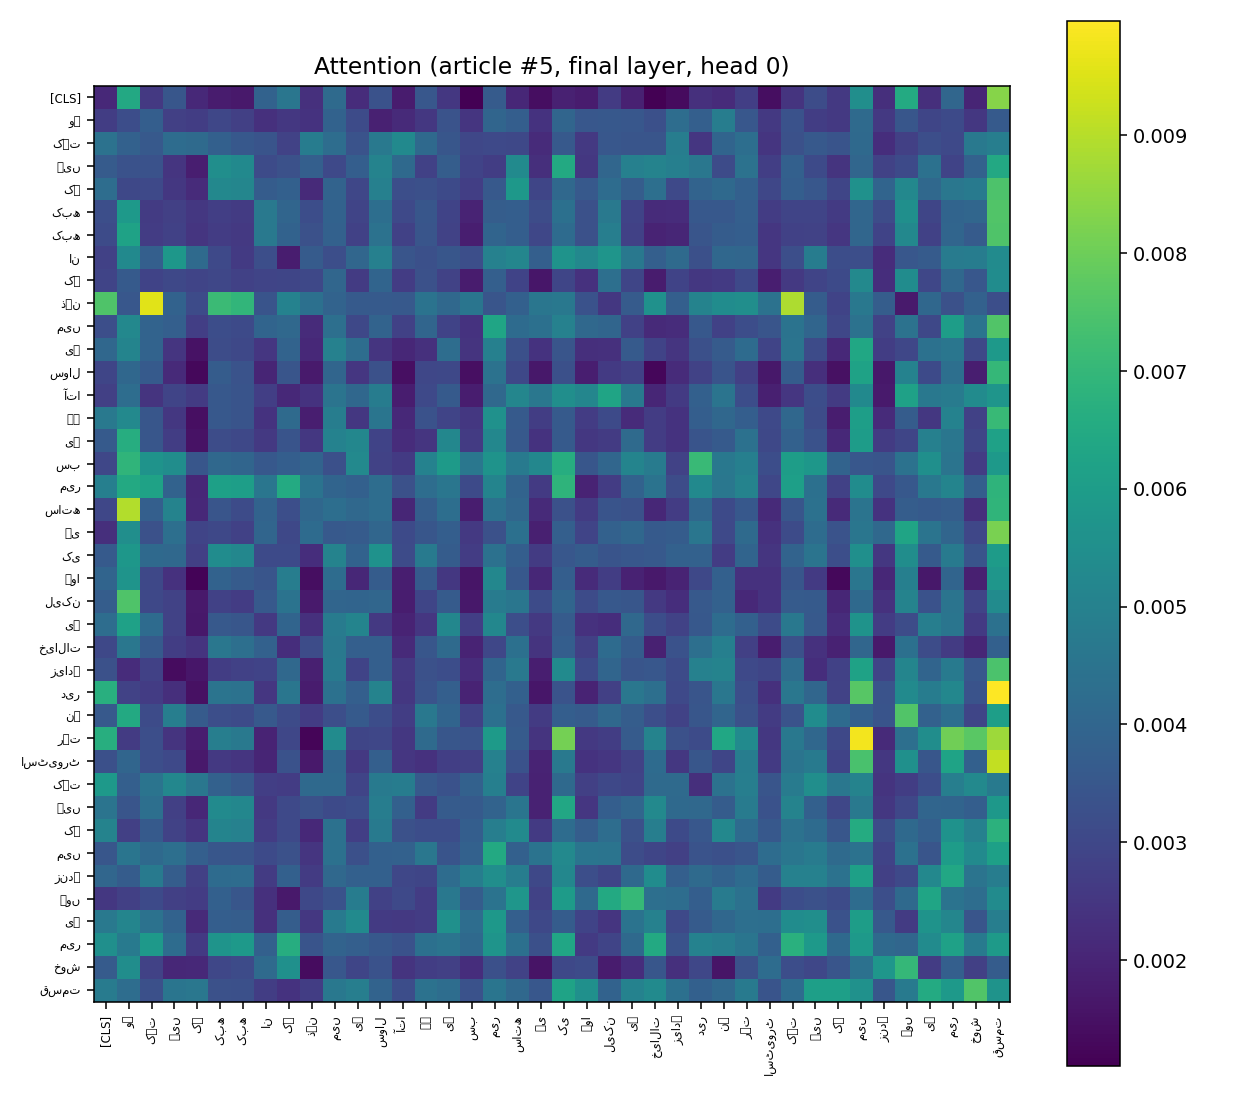

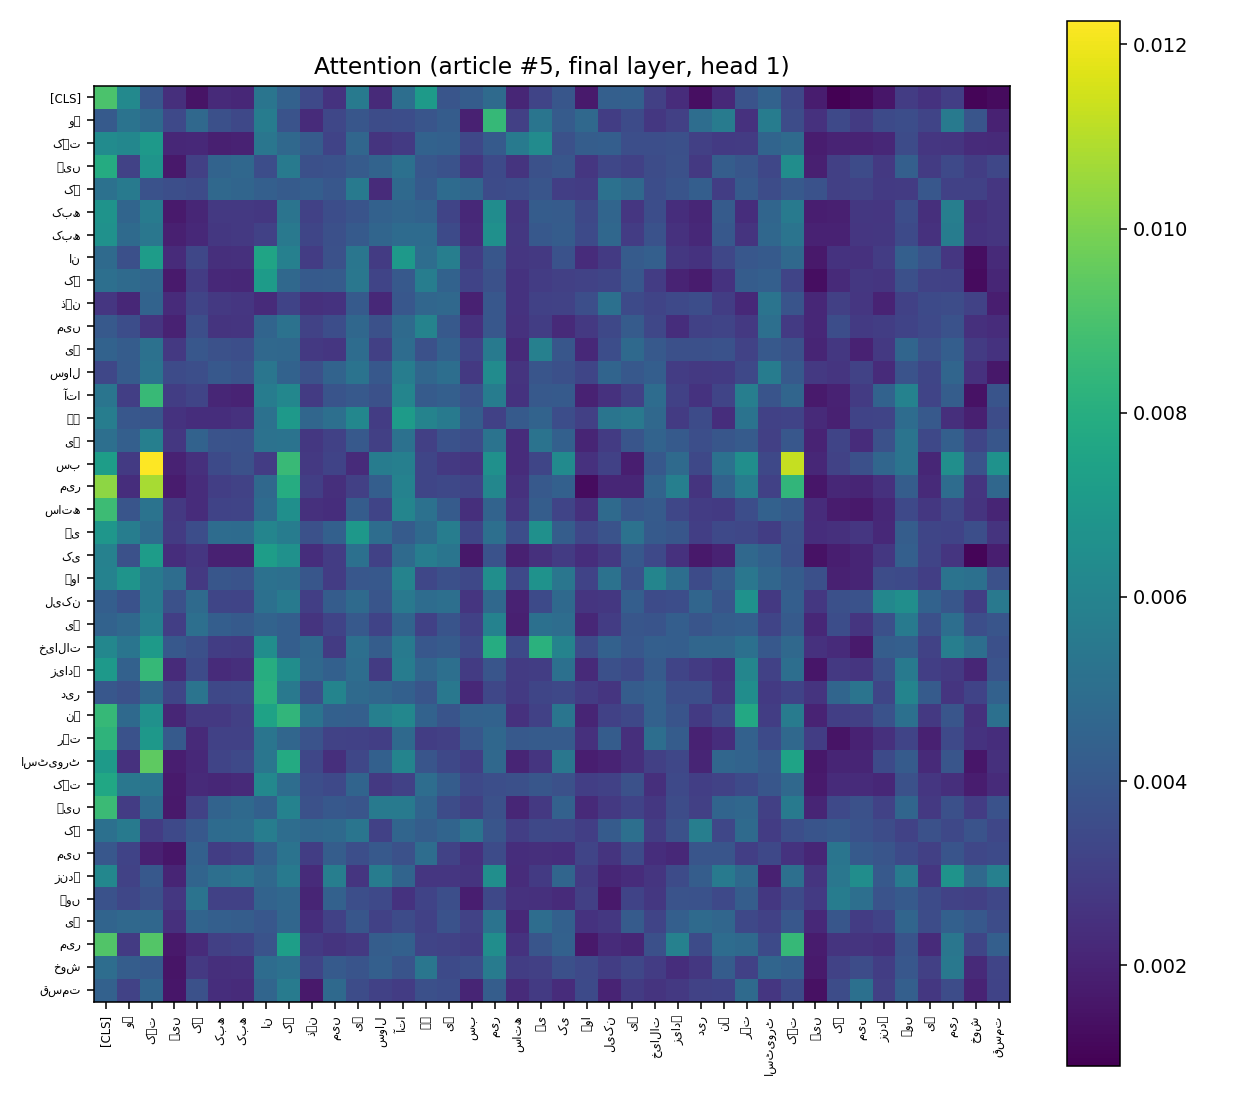

In [21]:
for f in sorted(FIG.glob('attn_*.png')):
    display(Image(str(f)))

### 8.2 BiLSTM vs. Transformer (10–15 sentences)
1. **Accuracy.** On this corpus the BiLSTM-CRF is strong for sequence labelling (POS and NER), while the Transformer achieves the higher *topic classification* accuracy because a single `[CLS]` representation can integrate whole-article context — numeric comparison of the two macro-F1 values is printed in the result cell above.
2. **Convergence.** The BiLSTM converges in ~10 epochs thanks to pretrained embeddings and a narrow output space; the Transformer needs all 20 epochs (AdamW + cosine) to exploit the 4-layer depth, even though it begins from random weights.
3. **Wall-clock per epoch.** BiLSTM is faster per epoch (≈1–2 s on MPS for 348 sentences × 40 tokens). The Transformer is heavier because every encoder block computes 4-head O(T²) attention across 256-token sequences — roughly ×3 of the BiLSTM step cost, but still well inside seconds.
4. **Attention heatmaps.** The plotted heads focus on topic-salient nouns (`پاکستان`, `ٹیم`, `ہسپتال`, `ایران`), and the `[CLS]` row tends to attend broadly to domain-indicative tokens, confirming the model is content-driven rather than position-driven.
5. **200–300 articles.** With so little data, the BiLSTM-CRF is a better choice: pretrained embeddings (C3) carry most of the semantic burden, recurrent inductive bias exploits local ordering, and the architecture has far fewer parameters to regularise. A from-scratch Transformer, even tiny, typically over-fits this regime; one would need either much more data or transfer-learned weights (disallowed here) to justify it.

## GitHub Submission
Repository: <https://github.com/WaleedSaeed027/121-1672-NLP-Assignment2

The folder layout mirrors the zip submission (`embeddings/`, `models/`, `data/`). The commit history reflects incremental progress across the three parts. Reproduction:

```bash
python3 scripts/prep_corpus.py
python3 scripts/part1_embeddings.py
python3 scripts/part2_annotate.py
python3 scripts/part2_bilstm.py
python3 scripts/part3_transformer.py
jupyter nbconvert --to notebook --execute i21-1672_Assignment2_DS-A.ipynb
```